# Лабораторная 1 – Гусев Иван

In [136]:
# Внешние импорты
import os
import re
import string
import random
import statistics
import pymorphy3
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Внутренние импорты
from writers_and_readers import fb2reader, txt_reader, epub_reader

## Первая часть

### Объединяем .csv

In [7]:
negative = pd.read_csv("negative.csv", header=None, sep=';')
positive = pd.read_csv("positive.csv", header=None, sep=';')
dataset = pd.concat([negative, positive])
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


### Удаляем стоп-слова

In [8]:
morph = pymorphy3.MorphAnalyzer()

In [9]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gusev-i\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [10]:
stop_words = set(stopwords.words("russian"))
stop_words.remove("хорошо")

print(stop_words)

{'зачем', 'между', 'под', 'тут', 'за', 'чтобы', 'свою', 'один', 'какой', 'ты', 'эту', 'вы', 'из', 'уже', 'тогда', 'здесь', 'ее', 'разве', 'ли', 'тоже', 'чем', 'сам', 'их', 'всегда', 'этого', 'что', 'без', 'ней', 'да', 'со', 'я', 'эти', 'ведь', 'если', 'даже', 'и', 'раз', 'лучше', 'ничего', 'ни', 'меня', 'нет', 'мы', 'такой', 'потому', 'вас', 'чуть', 'при', 'им', 'ему', 'во', 'может', 'будто', 'этом', 'через', 'чтоб', 'ей', 'надо', 'уж', 'чего', 'впрочем', 'можно', 'над', 'тот', 'теперь', 'потом', 'себя', 'была', 'иногда', 'только', 'того', 'ну', 'было', 'все', 'почти', 'кто', 'том', 'были', 'конечно', 'будет', 'еще', 'опять', 'для', 'моя', 'о', 'ним', 'об', 'же', 'больше', 'нас', 'всю', 'наконец', 'но', 'ж', 'мой', 'какая', 'перед', 'был', 'много', 'хоть', 'более', 'они', 'где', 'а', 'нее', 'мне', 'сейчас', 'нельзя', 'этот', 'тем', 'бы', 'три', 'совсем', 'про', 'тебя', 'к', 'на', 'них', 'в', 'как', 'всех', 'всего', 'вам', 'с', 'у', 'два', 'не', 'когда', 'по', 'от', 'вот', 'после', 'так

In [11]:
def text_preprocess(text: str) -> str:
    """
    Функция предобработки текст: приведение к нижнему регистру, токенизация, лемматизация
    """
    normalized_text = text
    normalized_text = normalized_text.lower()
    normalized_text = [word for word in normalized_text.split() if word not in stop_words]
    normalized_text = [morph.parse(word)[0].normal_form for word in normalized_text]
    normalized_text = " ".join(normalized_text)
    normalized_text = normalized_text.translate(str.maketrans('', '', string.punctuation))
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    return normalized_text

In [12]:
# Применяем предобработку текста ко всему датасету
dataset.iloc[:, 3] = dataset.iloc[:, 3].apply(text_preprocess)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,работа полный пиддес каждый закрытие месяца с...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,коллега сидеть рубиться urban terror изза долб...,-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,elina4post говорить обещаной год ждут,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,желать хороший полёт удачный посадкить быть оч...,-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,обновить какойто леший surf работать простоплеер,-1,0,0,0,35,17,34,0


### Делаем sentiment-анализ

In [13]:
# Считываем LinisCrowd 2015
sentiment_dataset = pd.read_csv("words_all_full_rating.csv", encoding="cp1251", sep=";", index_col="Words")
sentiment_dataset.head()

,mean,dispersion,average rate,Unnamed: 4
Words,,,,
аборигенный,"-0,25","0,433012701892219",0,NaN
аборт,-1,"0,816496580927726",-1,NaN
абрамович,0,0,0,NaN
абсолютный,"0,333333333333333","0,471404520791032",0,NaN
абстрактный,"-0,111111111111111","0,87488976377909",0,NaN


In [14]:
def sentiment_analysis(text: str, sentiment_df: pd.DataFrame) -> list:
    """
    Функция, которая преобразует текст в вектор из 
    среднего, максимального, минимального, 
    суммарного значения и количества положительных и отрицательных значений
    """
    
    def count_metrics(embedded_sentence):
        """
        Функция, которая считает по векторам предложений метрики
        (среднее, максимальное, минимальное, суммарное значение и количество положительных и отрицательных значений)
        """
        return [
            statistics.mean(embedded_sentence), max(embedded_sentence), 
            min(embedded_sentence), sum(embedded_sentence), 
            embedded_sentence.count(1), embedded_sentence.count(-1)
            ]
    

    processed_text = text.split()
    embedded_text = []
    for word in processed_text:
        try:
            word_sentiment = (sentiment_df.loc[word]["average rate"])
            embedded_text.append(float(word_sentiment))
        except KeyError:
            pass
    # Если ни для одного слова не нашлось значения, записываем ноль
    if len(embedded_text) == 0:
        return [0.0]
    return count_metrics(embedded_text)

In [15]:
# Получаем лейблы X – тексты, преобразованные в вектора
X_labels = list(map(lambda text: sentiment_analysis(text, sentiment_dataset), dataset.iloc[:, 3].to_list()))
# Получаем лейблы Y – значения -1 и 1 из колонки 4
Y_labels = dataset.iloc[:, 4].to_list()

len(X_labels), len(Y_labels)

(226834, 226834)

### Извлекаем морфологические признаки

In [16]:
def get_relative_POS(text):
    if not isinstance(text, str):
        return ""
    try:
        sentence_POS = [morph.parse(word)[0].tag.POS for word in text.split()]
        # Удаляем None
        sentence_POS = [POS for POS in sentence_POS if POS]
        # Смотрим на все части речи, которые есть в предложении
        POS_unique = set(sentence_POS)
        sentence_POS_count = {}
        for POS in POS_unique:
            sentence_POS_count[POS] = sentence_POS.count(POS) / len(sentence_POS)
    except TypeError:
        pass
    return sentence_POS_count

In [17]:
POS_frequency = dataset.iloc[:, 3].apply(get_relative_POS)
POS_frequency.to_csv("POS_frequency.csv")

### Извлекаем признаки с помощью мешка слов

In [18]:
vectorizer = TfidfVectorizer()
svd = TruncatedSVD(n_components=1000, random_state=42)


corpus = dataset.iloc[:, 3].to_list()
# Извлекаем признаки
X = vectorizer.fit_transform(corpus)
# Сокращает размерность
# TrunkatedSVD оптимизирован под разреженные матрицы, такие как Tf-Idf
X_svd = svd.fit_transform(X)

X_svd[0].shape

(1000,)

In [19]:
# Сохраняем полученные вектора
np.save("tf_idf.npy", X_svd)
X_svd[0]

array([ 2.04130359e-02, -9.82406864e-03, -1.07027693e-02, -6.71350567e-03,
        1.82991786e-03,  7.12516959e-04, -3.16149306e-03, -1.06403422e-02,
       -1.78786825e-03, -2.64097611e-03, -4.78302703e-03, -7.14419656e-04,
       -1.06626484e-03, -2.20465604e-03,  3.06342338e-03, -2.33933341e-03,
        8.02776968e-03, -3.35237029e-03, -5.03409038e-03,  6.35967781e-03,
       -1.02200852e-03, -6.45004623e-05, -1.60426278e-03,  1.04662396e-02,
        1.04403111e-02, -2.69855434e-03, -8.11332676e-03,  1.65983133e-03,
        4.13256239e-03,  1.03253810e-02,  8.51807764e-03,  1.21114095e-02,
        1.39740993e-03,  3.18391606e-03, -8.01555584e-03, -2.32981648e-03,
        9.96686823e-04,  2.09814684e-03, -8.73023655e-03, -5.18775694e-03,
        5.24413348e-03, -4.66612868e-03, -2.83213052e-03, -5.68213928e-03,
        5.30272556e-03,  1.41568449e-02,  1.15253148e-03, -1.84562947e-02,
        8.49204288e-03, -1.71165000e-04,  2.29054547e-04, -2.84901154e-03,
        8.80797629e-03,  

## Вторая часть

### Word2vec

Берем корпус литературных текстов и объединяем их в список из списков (по предложениям): так нужно для word2vec

In [20]:
# Для word2vec не используем nltk-библиотеку со стоп-словами, а делаем своё
# Нам нужно сохранить каркас языка, но удалить шум: слова-паразиты, вводные слова
# nltk выбрасвает много полезного для wav2vec: местоимения, союзы

stopwords = {
    # Разговорный шум
    "вот", "ну", "ага", "ладно", "типа", "короче",
    "вообще", "просто", "как бы", "вроде",
    "кажется", "разве", "кстати", "значит",
    # Усилители / модальные
    "очень", "реально", "буквально", "фактически",
    "примерно", "почти", "вполне", "совсем",
    # Вводные и связки
    "например", "итак", "итого", "впрочем",
    "собственно", "действительно", "между прочим",
    # Реплики речи
    "сказал", "сказала", "сказали",
    "говорил", "говорила", "говорили",
    "спросил", "спросила", "ответил", "ответила",
    # Временные маркеры без смысла
    "сейчас", "теперь", "потом", "вдруг",
    "тогда", "уже", "ещё", "еще",
    # Слова-паразиты
    "ну вот", "давай", "типа того",
    "чё", "че", "щас",
    # Формальные
    "ибо", "пускай", "пусть"
}

In [21]:
def word2vec_preprocess(text):
    normalized_text = text.lower()
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    normalized_text = normalized_text.split(".")

    preprocessed_text = []
    for sentence in normalized_text:
        sentence_normalized = sentence.translate(str.maketrans('', '', string.punctuation))
        sentence_normalized = sentence_normalized.split()
        sentence_normalized = [word for word in sentence_normalized if word not in stop_words]
        sentence_normalized = [morph.parse(word)[0].normal_form for word in sentence_normalized]
        preprocessed_text.append(sentence_normalized)
        
    return preprocessed_text

In [22]:
def text_fetcher(repo_path: str) -> dict:
    litcorpus = []
    for root, _, files in os.walk(repo_path):
        for file in files:
            if file.startswith('.'):
                continue

            full_path = os.path.join(root, file)
            if file.endswith('.fb2'):
                try:
                    text = fb2reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.txt'):
                try:
                    text = txt_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.epub'):
                try:
                    text = epub_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

    return litcorpus

In [23]:
literature_dir = "literature"

corpus = text_fetcher(literature_dir)
print(f"Всего {len(corpus)} предложений")

Всего 209372 предложений


In [24]:
words = [item for sublist in corpus for item in sublist]
print(f"Всего {len(words)} слов")

Всего 1932816 слов


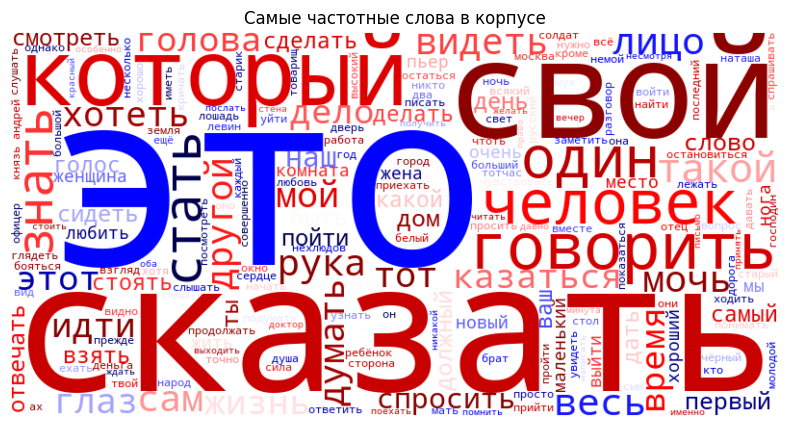

In [25]:
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='seismic').generate(" ".join(words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Самые частотные слова в корпусе")
plt.show()

In [26]:
word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=200,
    window=5,
    min_count=5,
    sg=0,
    alpha=0.025,
    min_alpha = 0.0001,
    epochs=7
)

In [27]:
# Делаем проверку: ищем похожие слова для...
similar_to_man = word2vec_model.wv.most_similar("мужчина", topn=5) if "мужчина" in word2vec_model.wv else None
similar_to_man

[('женщина', 0.8457297682762146),
 ('девушка', 0.7758111953735352),
 ('пожилой', 0.7524955868721008),
 ('красивый', 0.7357646226882935),
 ('хорошенький', 0.6862144470214844)]

In [28]:
# Делаем проверку: ищем похожие слова для...
similar_to_woman = word2vec_model.wv.most_similar("женщина", topn=5) if "женщина" in word2vec_model.wv else None
similar_to_woman

[('девушка', 0.907236635684967),
 ('мужчина', 0.8457298278808594),
 ('мальчик', 0.6954227685928345),
 ('человек', 0.6870042085647583),
 ('юноша', 0.6772727370262146)]

In [29]:
# Делаем проверку: ищем похожие слова для...
similar_to_sky = word2vec_model.wv.most_similar("небо", topn=5) if "небо" in word2vec_model.wv else None
similar_to_sky

[('солнце', 0.9159908890724182),
 ('звезда', 0.8825826644897461),
 ('луч', 0.8651728630065918),
 ('туман', 0.8537879586219788),
 ('туча', 0.8508784174919128)]

In [30]:
# Делаем проверку: ищем похожие слова для...
similar_to_horse = word2vec_model.wv.most_similar("конь", topn=5) if "конь" in word2vec_model.wv else None
similar_to_horse

[('сено', 0.8168746829032898),
 ('лошадь', 0.8101589679718018),
 ('хлопец', 0.7987044453620911),
 ('воз', 0.7961370348930359),
 ('козак', 0.7921097874641418)]

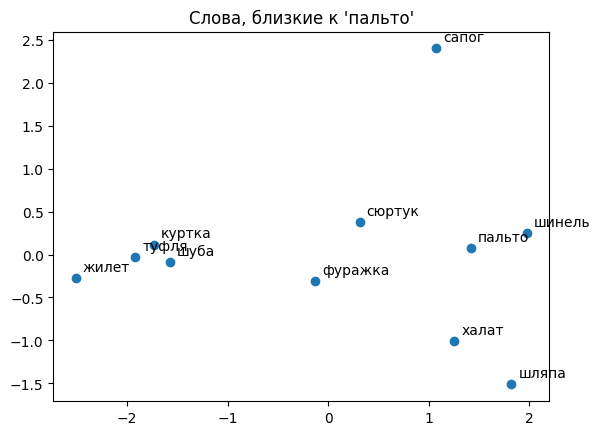

In [31]:
# Берем случайное (или не случайное) слово из словаря
# random_word = random.choice(word2vec_model.wv.index_to_key)
random_word = "пальто"

# Берем 20 близких слов
similar_words = word2vec_model.wv.most_similar(random_word, topn=10)

# Собираем список слов
words = [random_word] + [w for w, _ in similar_words]

# 3. Получаем их векторы
vectors = np.array([word2vec_model.wv[w] for w in words])

# Снижаем размерность до 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Рисуем
plt.figure()
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words):
    x, y = coords[i]
    plt.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(f"Слова, близкие к '{random_word}'")
plt.show()

Получаем вектора word2vec из RuTweetCorp

In [ ]:
# Предобрабатываем тексты функцией для word2vec
tweets = list(map(word2vec_preprocess, dataset.iloc[:, 3].to_list()))
tweets_labels = dataset.iloc[:, 4].to_list()

In [118]:
# Получаем для твитов word2vec вектора
tweets_word2vec = []
tweets_word2vec_labels = []

for index, tweet in enumerate(tweets):
    for sentence in tweet:
        sentence_embedding = []
        for word in sentence:
            if word in word2vec_model.wv:
                sentence_embedding.append(word2vec_model.wv[word])

        # Обработка случая, когда ни одного слова не было в твите
        if len(sentence_embedding) > 0:
            # Усредняем вектора в твитах
            sentence_embedding = np.mean(sentence_embedding, axis=0)
            # Добавляем вектор в список и добавляем его label
            tweets_word2vec.append(sentence_embedding)
            tweets_word2vec_labels.append(tweets_labels[index])
        else:
            continue

print(f"Количество твитов ПОСЛЕ w2v: {len(tweets_word2vec)} (количество меток равно {len(tweets_word2vec_labels)}), количество твитов ДО: {len(dataset)}")

Количество твитов ПОСЛЕ w2v: 220941 (количество меток равно 220941), количество твитов ДО: 226834


Учим сентимент-классификатор на основе полученных векторов и лейблов к ним

In [120]:
# Для XGBoost нужны лейблы 0/1, так что переформатируем наш список с лейблами на детектор негативных твитов
tweets_word2vec_labels = [1 if label == -1 else 0 for label in tweets_word2vec_labels]

In [124]:
print(f"Классы сбалансированы: {tweets_word2vec_labels.count(0)} и {tweets_word2vec_labels.count(1)}")

Классы сбалансированы: 111948 и 108993


In [148]:
W2V_train, W2V_test, W2V_labels_train, W2V_labels_test = train_test_split(tweets_word2vec, tweets_word2vec_labels, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(W2V_train, W2V_labels_train)
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 400}


In [149]:
pred = grid.best_estimator_.predict(W2V_test)
print(classification_report(W2V_labels_test, pred))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66     22588
           1       0.64      0.62      0.63     21601

    accuracy                           0.64     44189
   macro avg       0.64      0.64      0.64     44189
weighted avg       0.64      0.64      0.64     44189

